# Segmentation metrics

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import random
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import TensorDataset
from model.model import UNet1D_Embed


# ============================================================
# CONFIG
# ============================================================

GT_FILE = "/path/to/reference"
MODEL_FILE = "/path/to/model"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE = 512
MAX_LEN = 512
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)
# Threshold for nucleotide-level segmentation
SEG_THRESHOLD = 0.1

COORDINATES_ARE_1_BASED = False

PADDING = 5

CHAR_TO_ID = {
    "A": 0,
    "C": 1,
    "G": 2,
    "T": 3,
    "N": 4,
    "P": 5,
}

RC_TABLE = torch.tensor(
    [3, 2, 1, 0, 4, 5],
    dtype=torch.long
)

In [2]:
MODEL_FILE = "../model_with_all.pth"

BATCH_SIZE = 256
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SEG_THRESHOLDS = np.arange(0.1, 1.0, 0.1)
PADDING = 5


# ============================================================
# REVERSE COMPLEMENT
# ============================================================

def reverse_complement(x):
    lengths = (x != PADDING).sum(dim=1)
    L = x.shape[1]

    table = RC_TABLE.to(x.device)
    x_rc = table[x].flip(1)

    pos = torch.arange(L, device=x.device).unsqueeze(0)

    src = (
        L - lengths.unsqueeze(1) + pos
    ).clamp(0, L - 1)

    rc_seq = torch.gather(
        x_rc,
        dim=1,
        index=src
    )

    result = torch.full_like(x, PADDING)

    mask = pos < lengths.unsqueeze(1)
    result[mask] = rc_seq[mask]

    return result


# ============================================================
# REVERSE PREDICTION -> FORWARD
# ============================================================

def reverse_to_forward(mask, lengths):
    result = torch.zeros_like(mask)

    for i, length in enumerate(lengths.tolist()):
        if length > 0:
            result[i, :length] = mask[i, :length].flip(0)

    return result


# ============================================================
# PREDICTIONS
# ============================================================

@torch.inference_mode()
def get_predictions(model, x, lengths):

    # Forward
    cdr_f, v_f, j_f = model(x)

    # Reverse complement
    x_rc = reverse_complement(x)
    cdr_r, v_r, j_r = model(x_rc)

    # Back to original orientation
    cdr_r = reverse_to_forward(cdr_r, lengths)
    v_r = reverse_to_forward(v_r, lengths)
    j_r = reverse_to_forward(j_r, lengths)

    # Logits -> probabilities
    cdr_f, v_f, j_f = map(
        torch.sigmoid,
        (cdr_f, v_f, j_f)
    )

    cdr_r, v_r, j_r = map(
        torch.sigmoid,
        (cdr_r, v_r, j_r)
    )

    # Choose strand using V + J signal
    score_f = v_f.amax(dim=1) + j_f.amax(dim=1)
    score_r = v_r.amax(dim=1) + j_r.amax(dim=1)

    use_reverse = (score_r > score_f).unsqueeze(1)

    # Select strand
    cdr = torch.where(use_reverse, cdr_r, cdr_f)
    v = torch.where(use_reverse, v_r, v_f)
    j = torch.where(use_reverse, j_r, j_f)

    return cdr, v, j


# ============================================================
# BINARY METRICS
# ============================================================

def calculate_metrics(y_true, y_pred):

    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)

    tp = np.logical_and(y_true, y_pred).sum()
    fp = np.logical_and(~y_true, y_pred).sum()
    fn = np.logical_and(y_true, ~y_pred).sum()

    precision = (
        tp / (tp + fp)
        if tp + fp > 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if tp + fn > 0
        else 0.0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0
        else 0.0
    )

    iou = (
        tp / (tp + fp + fn)
        if tp + fp + fn > 0
        else 0.0
    )

    return {
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "IoU": iou
    }


# ============================================================
# BOUNDARY ERRORS
# ============================================================

def boundary_errors(y_true, y_pred):

    true_pos = np.where(y_true)[0]
    pred_pos = np.where(y_pred)[0]

    # No ground-truth region
    if len(true_pos) == 0:
        return None

    # Entire region missed
    if len(pred_pos) == 0:
        return {
            "start_error": np.nan,
            "end_error": np.nan,
            "missed": True
        }

    true_start = true_pos[0]
    true_end = true_pos[-1] + 1

    pred_start = pred_pos[0]
    pred_end = pred_pos[-1] + 1

    return {
        "start_error": abs(pred_start - true_start),
        "end_error": abs(pred_end - true_end),
        "missed": False
    }


# ============================================================
# MAIN
# ============================================================

def main():

    # --------------------------------------------------------
    # Load X and y
    # --------------------------------------------------------

    print("Loading X and y...")

    X = torch.load(
        '/path/to/dataset.pt',
        weights_only=True
    )['X'].long()

    y = torch.load(
       '/path/to/dataset/pt',
        weights_only=True
    )['y']

    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")

    dataset = torch.utils.data.TensorDataset(
        X,
        y
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    print("Loading model...")

    model = UNet1D_Embed().to(DEVICE)

    state_dict = torch.load(
        MODEL_FILE,
        map_location=DEVICE,
        weights_only=True
    )

    model.load_state_dict(state_dict)
    model.eval()

    # --------------------------------------------------------
    # Storage
    # --------------------------------------------------------
    all_true,all_pred, boundary_results={},{},{}
    for i in SEG_THRESHOLDS:
        all_true[i] = {
        "cdr3": [],
        "v": [],
        "j": []}
        all_pred[i] = {
        "cdr3": [],
        "v": [],
        "j": []}
        boundary_results[i] = {
        "cdr3": [],
        "v": [],
        "j": []}

    # --------------------------------------------------------
    # Inference
    # --------------------------------------------------------

    print("Running inference...")
    for seg in SEG_THRESHOLDS:
        for batch_idx, (x, y_batch) in enumerate(loader):

            x = x.to(
                DEVICE,
                non_blocking=True
            )

            lengths = (
                x != PADDING
            ).sum(dim=1)

            cdr_prob, v_prob, j_prob = get_predictions(
                model,
                x,
                lengths
            )

            pred = {
                "cdr3": (
                    cdr_prob >= seg
                ).cpu().numpy(),

                "v": (
                    v_prob >= seg
                ).cpu().numpy(),

                "j": (
                    j_prob >= seg
                ).cpu().numpy()
            }


            y_batch = y_batch.numpy()



            for name, channel in [
                ("cdr3", 0),
                ("v", 1),
                ("j", 2)
            ]:

                true_batch = y_batch[:, channel]
                pred_batch = pred[name]

                all_true[seg][name].append(
                    true_batch
                )

                all_pred[seg][name].append(
                    pred_batch
                )

                for i in range(len(y_batch)):

                    result = boundary_errors(
                        true_batch[i],
                        pred_batch[i]
                    )

                    if result is not None:
                        boundary_results[seg][name].append(
                            result
                        )

            # ----------------------------------------------------
            # Progress
            # ----------------------------------------------------

            if batch_idx % 10 == 0:

                processed = min(
                    (batch_idx + 1) * BATCH_SIZE,
                    len(dataset)
                )

                print(
                    f"Processed "
                    f"{processed:,} / {len(dataset):,}"
                )

    # ========================================================
    # RESULTS
    # ========================================================

    print()
    print("=" * 70)
    print("SEGMENTATION RESULTS")
    print("=" * 70)
    metrics_all,errors_all={},{}
    for i in SEG_THRESHOLDS:
        errors_all[i] = {
        "cdr3": [],
        "v": [],
        "j": []}
        metrics_all[i] = {
        "cdr3": [],
        "v": [],
        "j": []}
    for seg in SEG_THRESHOLDS:
        print(f"Results for Threshold:{seg}\n--------------------------------------------\n")
        for name in ["v", "j", "cdr3"]:

            y_true = np.concatenate(
                all_true[seg][name],
                axis=0
            )

            y_pred = np.concatenate(
                all_pred[seg][name],
                axis=0
            )

            metrics = calculate_metrics(
                y_true,
                y_pred
            )

            print()
            print(name.upper())
            metrics_all[seg][name]=metrics
            print(
                f"Precision : "
                f"{metrics['Precision']:.4f}"
            )

            print(
                f"Recall    : "
                f"{metrics['Recall']:.4f}"
            )

            print(
                f"F1        : "
                f"{metrics['F1']:.4f}"
            )

            print(
                f"IoU       : "
                f"{metrics['IoU']:.4f}"
            )

            print(
                f"TP        : "
                f"{metrics['TP']:,}"
            )

            print(
                f"FP        : "
                f"{metrics['FP']:,}"
            )

            print(
                f"FN        : "
                f"{metrics['FN']:,}"
            )

            # ----------------------------------------------------
            # Boundary errors
            # ----------------------------------------------------

            boundaries = boundary_results[seg][name]

            start_errors = np.array([
                r["start_error"]
                for r in boundaries
                if not np.isnan(r["start_error"])
            ])

            end_errors = np.array([
                r["end_error"]
                for r in boundaries
                if not np.isnan(r["end_error"])
            ])

            missed = sum(
                r["missed"]
                for r in boundaries
            )
            errors_all[seg][name]=[np.median(start_errors),np.median(end_errors),np.mean(start_errors),np.mean(end_errors)]
            if len(start_errors) > 0:

                print(
                    f"Median start error : "
                    f"{np.median(start_errors):.2f} nt"
                )

                print(
                    f"Median end error   : "
                    f"{np.median(end_errors):.2f} nt"
                )

                print(
                    f"Mean start error   : "
                    f"{np.mean(start_errors):.2f} nt"
                )

                print(
                    f"Mean end error     : "
                    f"{np.mean(end_errors):.2f} nt"
                )

            print(
                f"Missed regions     : "
                f"{missed:,}"
            )

    print()
    print("=" * 70)
    return metrics_all,errors_all

metrics_all, errors_all = main()

Loading X and y...
X shape: torch.Size([161042, 512])
y shape: torch.Size([161042, 3, 512])
Loading model...
Running inference...
Processed 256 / 161,042
Processed 2,816 / 161,042
Processed 5,376 / 161,042
Processed 7,936 / 161,042
Processed 10,496 / 161,042
Processed 13,056 / 161,042
Processed 15,616 / 161,042
Processed 18,176 / 161,042
Processed 20,736 / 161,042
Processed 23,296 / 161,042
Processed 25,856 / 161,042
Processed 28,416 / 161,042
Processed 30,976 / 161,042
Processed 33,536 / 161,042
Processed 36,096 / 161,042
Processed 38,656 / 161,042
Processed 41,216 / 161,042
Processed 43,776 / 161,042
Processed 46,336 / 161,042
Processed 48,896 / 161,042
Processed 51,456 / 161,042
Processed 54,016 / 161,042
Processed 56,576 / 161,042
Processed 59,136 / 161,042
Processed 61,696 / 161,042
Processed 64,256 / 161,042
Processed 66,816 / 161,042
Processed 69,376 / 161,042
Processed 71,936 / 161,042
Processed 74,496 / 161,042
Processed 77,056 / 161,042
Processed 79,616 / 161,042
Processed 82

In [6]:
import json
with open("data.json", "w") as filename:
    json.dump(metrics_all, filename, indent=4)

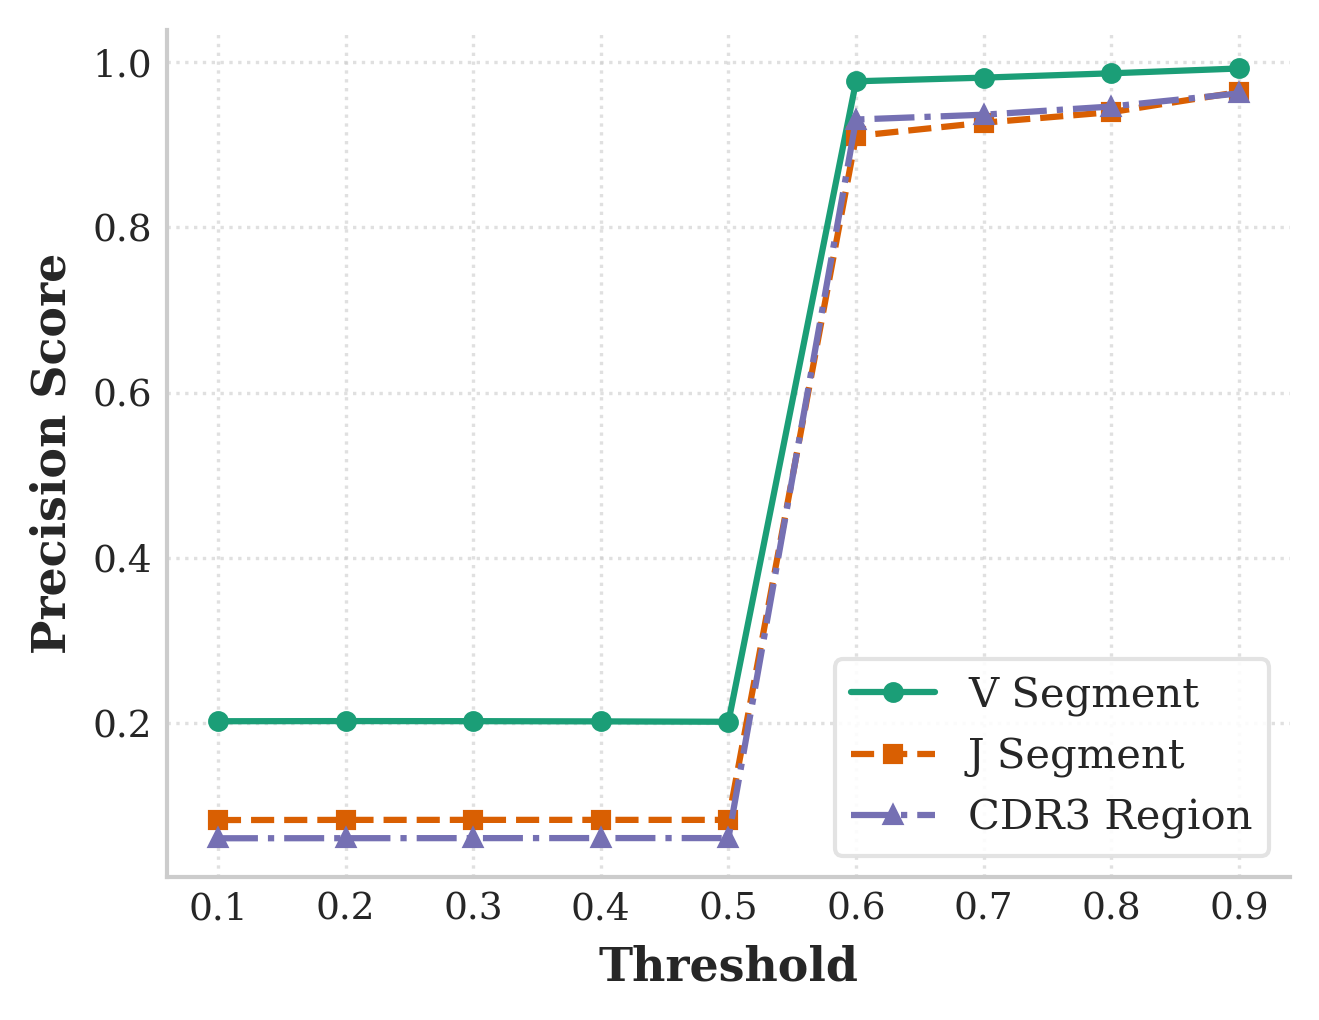

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Use an academic style sheet and define standard font sizes
plt.style.use('seaborn-v0_8-whitegrid')  # Clean canvas
plt.rcParams.update({
    'font.family': 'serif',         # Standard academic font (matches LaTeX/Time New Roman)
    'font.size': 10,                 # Standard journal text size
    'axes.labelsize': 11,           # Slightly larger axis labels
    'axes.titlesize': 12,           # Title size
    'xtick.labelsize': 9,           # Accessible tick sizes
    'ytick.labelsize': 9,
    'figure.titlesize': 12
})


Precision = {'V Segment': precision_v, 'J Segment': precision_j, 'CDR3 Region': precision_cdr3}

# 2. Set strict figure dimensions (Single column standard width is ~3.5 inches)
fig, ax = plt.subplots(figsize=(4.5, 3.5), dpi=300) # 300 DPI is required for print

# 3. High-contrast, colorblind-friendly palette with unique line styles
colors = ['#1b9e77', '#d95f02', '#7570b3']
linestyles = ['-', '--', '-.']
markers = ['o', 's', '^']

# Define x-axis cleanly using numpy array (includes 0.9 endpoint)
x = np.arange(0.1, 1.0, 0.1)

# Loop and plot with highly clear visual anchors
for i, (key, value) in enumerate(Precision.items()):
    ax.plot(x, value, 
            label=key, 
            color=colors[i], 
            linestyle=linestyles[i], 
            marker=markers[i], 
            markersize=4, 
            linewidth=1.5)

# 4. Academic labeling and formatting
ax.set_xlabel('Threshold', fontweight='bold')
ax.set_ylabel('Precision Score', fontweight='bold')

# 5. Clean, non-intrusive grid lines and frame layout
ax.grid(True, linestyle=':', alpha=0.6, color='#cccccc')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 6. Desaturated background frame for the legend
ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='#e0e0e0', framealpha=0.9)

plt.tight_layout()

# 7. Save figure in vector format (PDF/EPS) or high-res PNG for submission
plt.savefig('precision_metrics_plot.pdf', format='pdf', bbox_inches='tight')
plt.show()


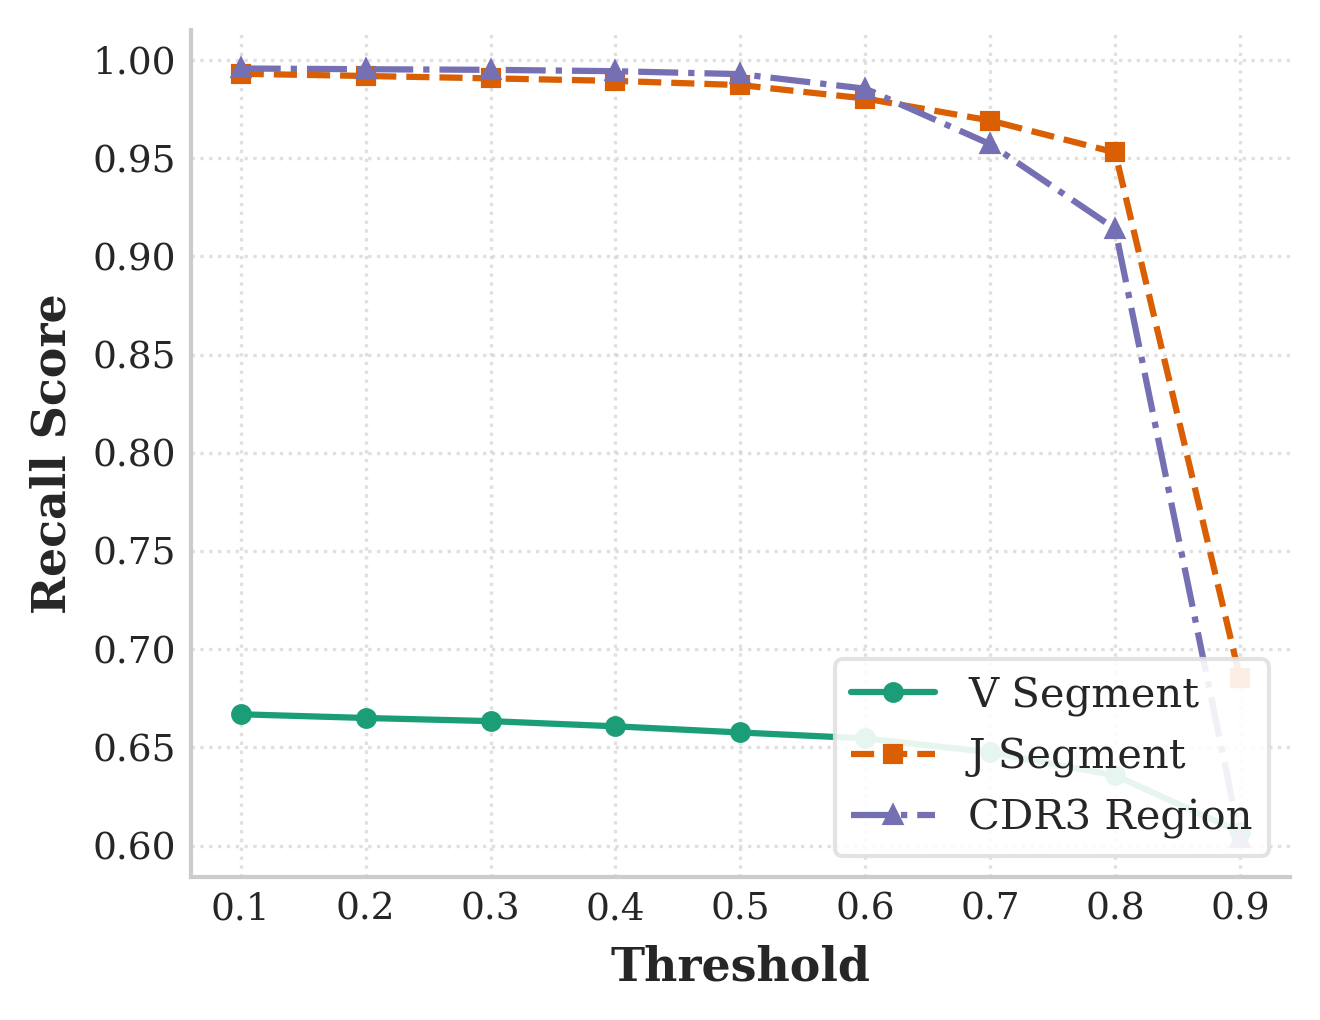

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Use an academic style sheet and define standard font sizes
plt.style.use('seaborn-v0_8-whitegrid')  # Clean canvas
plt.rcParams.update({
    'font.family': 'serif',         # Standard academic font (matches LaTeX/Time New Roman)
    'font.size': 10,                 # Standard journal text size
    'axes.labelsize': 11,           # Slightly larger axis labels
    'axes.titlesize': 12,           # Title size
    'xtick.labelsize': 9,           # Accessible tick sizes
    'ytick.labelsize': 9,
    'figure.titlesize': 12
})


Recall = {'V Segment': recall_v, 'J Segment': recall_j, 'CDR3 Region': recall_cdr3}

# 2. Set strict figure dimensions (Single column standard width is ~3.5 inches)
fig, ax = plt.subplots(figsize=(4.5, 3.5), dpi=300) # 300 DPI is required for print

# 3. High-contrast, colorblind-friendly palette with unique line styles
colors = ['#1b9e77', '#d95f02', '#7570b3']
linestyles = ['-', '--', '-.']
markers = ['o', 's', '^']

# Define x-axis cleanly using numpy array (includes 0.9 endpoint)
x = np.arange(0.1, 1.0, 0.1)

# Loop and plot with highly clear visual anchors
for i, (key, value) in enumerate(Recall.items()):
    ax.plot(x, value, 
            label=key, 
            color=colors[i], 
            linestyle=linestyles[i], 
            marker=markers[i], 
            markersize=4, 
            linewidth=1.5)

# 4. Academic labeling and formatting
ax.set_xlabel('Threshold', fontweight='bold')
ax.set_ylabel('Recall Score', fontweight='bold')

# 5. Clean, non-intrusive grid lines and frame layout
ax.grid(True, linestyle=':', alpha=0.6, color='#cccccc')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 6. Desaturated background frame for the legend
ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='#e0e0e0', framealpha=0.9)

plt.tight_layout()

# 7. Save figure in vector format (PDF/EPS) or high-res PNG for submission
plt.savefig('recall_metrics_plot.pdf', format='pdf', bbox_inches='tight')
plt.show()


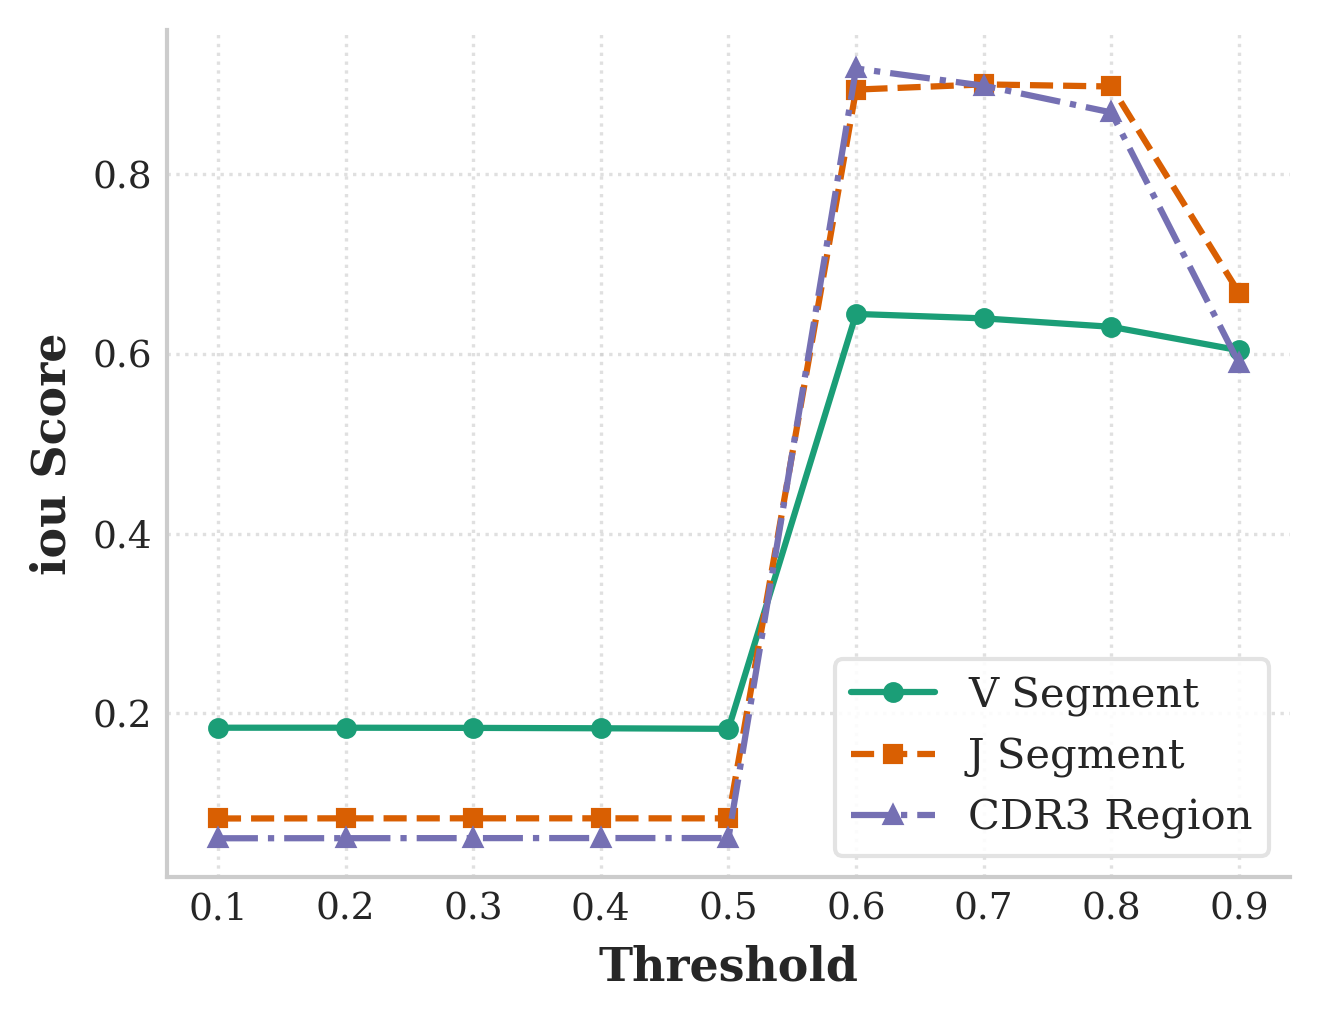

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Use an academic style sheet and define standard font sizes
plt.style.use('seaborn-v0_8-whitegrid')  # Clean canvas
plt.rcParams.update({
    'font.family': 'serif',         # Standard academic font (matches LaTeX/Time New Roman)
    'font.size': 10,                 # Standard journal text size
    'axes.labelsize': 11,           # Slightly larger axis labels
    'axes.titlesize': 12,           # Title size
    'xtick.labelsize': 9,           # Accessible tick sizes
    'ytick.labelsize': 9,
    'figure.titlesize': 12
})


IoU = {'V Segment': iou_v, 'J Segment': iou_j, 'CDR3 Region': iou_cdr3}

# 2. Set strict figure dimensions (Single column standard width is ~3.5 inches)
fig, ax = plt.subplots(figsize=(4.5, 3.5), dpi=300) # 300 DPI is required for print

# 3. High-contrast, colorblind-friendly palette with unique line styles
colors = ['#1b9e77', '#d95f02', '#7570b3']
linestyles = ['-', '--', '-.']
markers = ['o', 's', '^']

# Define x-axis cleanly using numpy array (includes 0.9 endpoint)
x = np.arange(0.1, 1.0, 0.1)

# Loop and plot with highly clear visual anchors
for i, (key, value) in enumerate(IoU.items()):
    ax.plot(x, value, 
            label=key, 
            color=colors[i], 
            linestyle=linestyles[i], 
            marker=markers[i], 
            markersize=4, 
            linewidth=1.5)

# 4. Academic labeling and formatting
ax.set_xlabel('Threshold', fontweight='bold')
ax.set_ylabel('iou Score', fontweight='bold')

# 5. Clean, non-intrusive grid lines and frame layout
ax.grid(True, linestyle=':', alpha=0.6, color='#cccccc')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 6. Desaturated background frame for the legend
ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='#e0e0e0', framealpha=0.9)

plt.tight_layout()

# 7. Save figure in vector format (PDF/EPS) or high-res PNG for submission
plt.savefig('iou_metrics_plot.pdf', format='pdf', bbox_inches='tight')
plt.show()


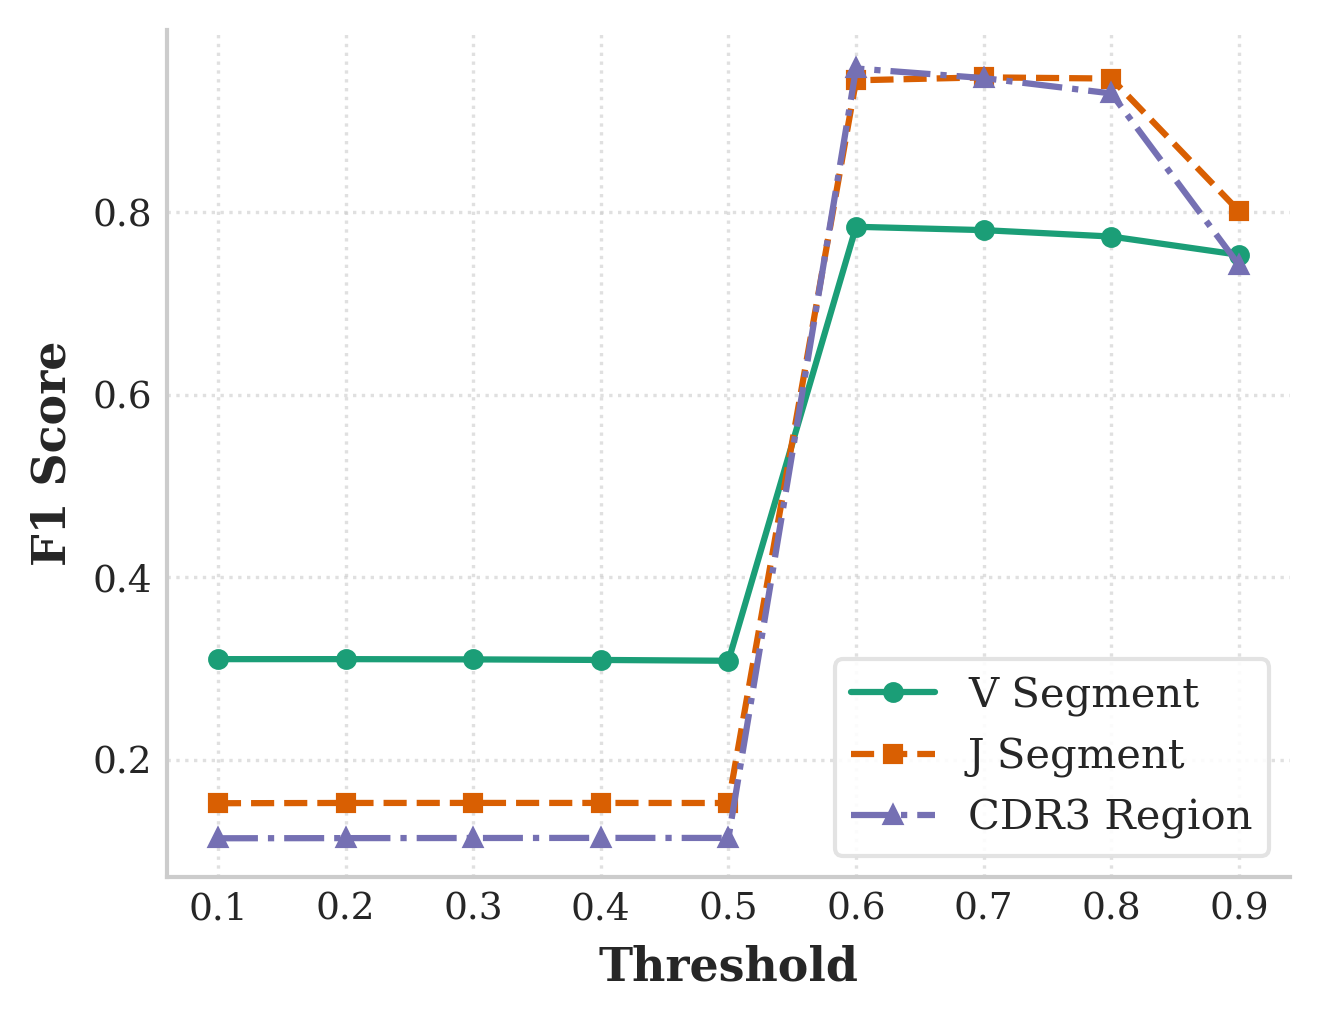

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Use an academic style sheet and define standard font sizes
plt.style.use('seaborn-v0_8-whitegrid')  # Clean canvas
plt.rcParams.update({
    'font.family': 'serif',         # Standard academic font (matches LaTeX/Time New Roman)
    'font.size': 10,                 # Standard journal text size
    'axes.labelsize': 11,           # Slightly larger axis labels
    'axes.titlesize': 12,           # Title size
    'xtick.labelsize': 9,           # Accessible tick sizes
    'ytick.labelsize': 9,
    'figure.titlesize': 12
})


f1 = {'V Segment': f1_v, 'J Segment': f1_j, 'CDR3 Region': f1_cdr3}

# 2. Set strict figure dimensions (Single column standard width is ~3.5 inches)
fig, ax = plt.subplots(figsize=(4.5, 3.5), dpi=300) # 300 DPI is required for print

# 3. High-contrast, colorblind-friendly palette with unique line styles
colors = ['#1b9e77', '#d95f02', '#7570b3']
linestyles = ['-', '--', '-.']
markers = ['o', 's', '^']

# Define x-axis cleanly using numpy array (includes 0.9 endpoint)
x = np.arange(0.1, 1.0, 0.1)

# Loop and plot with highly clear visual anchors
for i, (key, value) in enumerate(f1.items()):
    ax.plot(x, value, 
            label=key, 
            color=colors[i], 
            linestyle=linestyles[i], 
            marker=markers[i], 
            markersize=4, 
            linewidth=1.5)

# 4. Academic labeling and formatting
ax.set_xlabel('Threshold', fontweight='bold')
ax.set_ylabel('F1 Score', fontweight='bold')

# 5. Clean, non-intrusive grid lines and frame layout
ax.grid(True, linestyle=':', alpha=0.6, color='#cccccc')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 6. Desaturated background frame for the legend
ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='#e0e0e0', framealpha=0.9)

plt.tight_layout()

# 7. Save figure in vector format (PDF/EPS) or high-res PNG for submission
plt.savefig('f1_metrics_plot.pdf', format='pdf', bbox_inches='tight')
plt.show()
